## Name: Lavanya D
## Reg no: 212224060133
## Exp No:4
## Exp name: Simulation of Digital Modulation Techniques(Amplitude Shift Keying & Frequency Shift Keying)

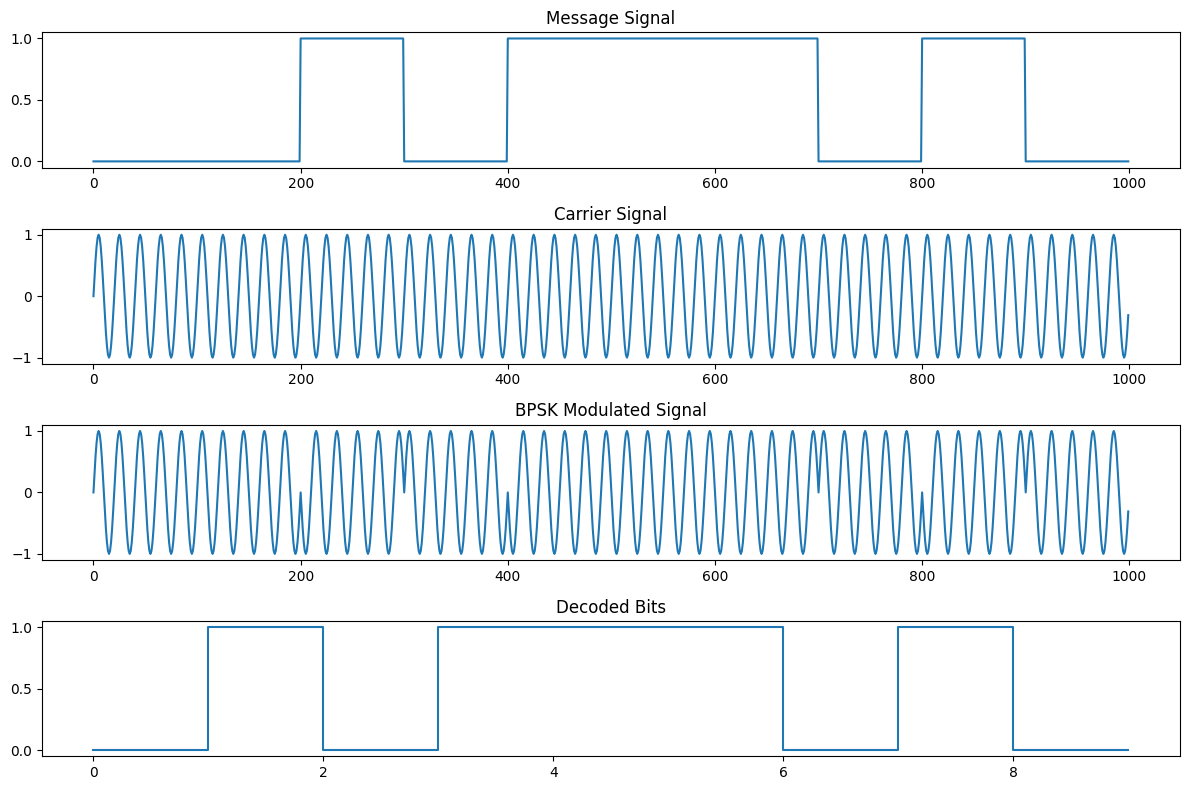

Original Bits: [0 0 1 0 1 1 1 0 1 0]
Decoded Bits : [0, 0, 1, 0, 1, 1, 1, 0, 1, 0]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000          # Sampling frequency
fc = 50            # Carrier frequency
bit_rate = 10      # Bits per second
Tb = 1 / bit_rate  # Bit duration
t = np.arange(0, 1, 1/fs)

# Generate random binary data
bits = np.random.randint(0, 2, bit_rate)

# Convert bits to signal
samples_per_bit = int(fs/bit_rate)
message = np.repeat(bits, samples_per_bit)

# Carrier signal
carrier = np.sin(2 * np.pi * fc * t)

# BPSK Modulation
psk_signal = np.zeros(len(message))

for i in range(len(message)):
    if message[i] == 0:
        psk_signal[i] = np.sin(2*np.pi*fc*t[i])
    else:
        psk_signal[i] = np.sin(2*np.pi*fc*t[i] + np.pi)

# Demodulation
demodulated = psk_signal * carrier

# Decision device
decoded_bits = []
for i in range(0, len(demodulated), samples_per_bit):
    sample = np.sum(demodulated[i:i+samples_per_bit])
    if sample > 0:
        decoded_bits.append(0)
    else:
        decoded_bits.append(1)

# Plotting
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(message)
plt.title("Message Signal")

plt.subplot(4,1,2)
plt.plot(carrier)
plt.title("Carrier Signal")

plt.subplot(4,1,3)
plt.plot(psk_signal)
plt.title("BPSK Modulated Signal")

plt.subplot(4,1,4)
plt.step(range(len(decoded_bits)), decoded_bits)
plt.title("Decoded Bits")
plt.tight_layout()
plt.show()
print("Original Bits:", bits)
print("Decoded Bits :", decoded_bits)